In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import boxplot
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

In [5]:
df=pd.read_csv("d:\\mohamedashraf-projecttt-copy\\archive\\cardio_train.csv", sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [6]:
df.shape

(70000, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [8]:
df.drop(['id'],axis=1,inplace=True)

In [9]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
df.value_counts()

age    gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  active  cardio
16160  1       168     65.0    120    80     1            1     0      0     1       1         2
18955  1       165     75.0    120    80     1            1     0      0     1       1         2
16793  1       165     68.0    120    80     1            1     0      0     1       0         2
18210  1       160     60.0    120    80     1            1     0      0     1       0         2
16805  1       157     67.0    120    80     1            1     0      0     1       0         2
                                                                                              ..
23667  1       156     75.0    100    80     1            1     0      0     0       0         1
               160     70.0    120    90     1            1     0      1     1       0         1
23668  1       169     80.0    120    80     1            1     0      0     1       0         1
               170     66.0    110 

**Convert "age" from Days To Years**

In [11]:
df['age_with_years']=df['age']//365
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_with_years
0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48
4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0,52
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1,61
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1,52
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61


In [12]:
df['age_with_years'].describe().round()

count    70000.0
mean        53.0
std          7.0
min         29.0
25%         48.0
50%         53.0
75%         58.0
max         64.0
Name: age_with_years, dtype: float64

In [13]:
df.drop(['age'],axis=1,inplace= True)

<Axes: >

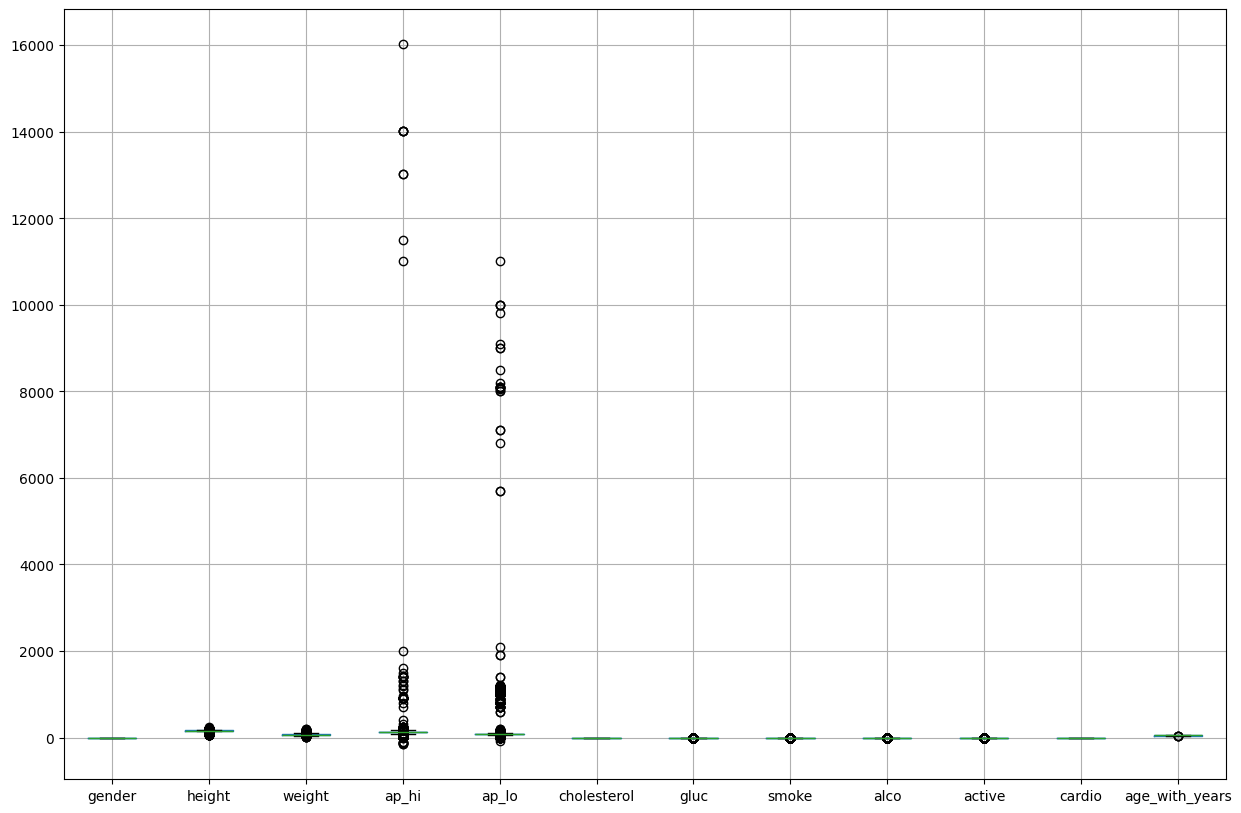

In [14]:
df.boxplot(figsize=(15,10))

featuer engineering


In [15]:
df['bmi'] = df['weight'] / ((df['height']/100) ** 2)

In [16]:
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=[0, 1, 2, 3]  # underweight, normal, overweight, obese
)

In [17]:
def bmi_risk(bmi):
    if bmi < 18.5:
        return 1
    elif bmi < 25:
        return 0
    elif bmi < 30:
        return 2
    else:
        return 3

df['bmi_risk'] = df['bmi'].apply(bmi_risk)

In [18]:
df['bmi_age'] = df['bmi'] * df['age_with_years']

In [19]:
df['bmi_bp'] = df['bmi'] * df['ap_hi']

In [20]:
df = df[(df['bmi'] > 10) & (df['bmi'] < 60)]

## **Handling Outlier** in ( ap_hi & ap_lo)

In [21]:

boxplot( df[['ap_hi','ap_lo']])

<Axes: >

In [22]:
print( " Count rows ap_hi > 250  is | ", (df['ap_hi'] > 250).sum()  )
print( " Count rows ap_lo > 200  is | ", (df['ap_lo'] > 200).sum()  )
print( " Count rows ap_lo > ap_hi  is | ", (df['ap_lo'] > df['ap_hi']).sum()  )

 Count rows ap_hi > 250  is |  40
 Count rows ap_lo > 200  is |  949
 Count rows ap_lo > ap_hi  is |  1229


In [23]:
mask = (
    (df['ap_hi'] > 250) |
    (df['ap_lo'] > 200) |
    (df['ap_hi'] < 50)  |
    (df['ap_lo'] < 30)  |
    (df['ap_lo'] >= df['ap_hi'])
)

df.drop(df[mask].index, inplace=True)

print(f" after deleting : {df.shape}")

 after deleting : (68611, 17)


C:\Users\hp\AppData\Local\Temp\ipykernel_19576\2968999494.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(df[mask].index, inplace=True)


In [24]:
print( " Count rows ap_hi > 250  is | ", (df['ap_hi'] > 250).sum()  )
print( " Count rows ap_lo > 200  is | ", (df['ap_lo'] > 200).sum()  )
print( " Count rows ap_lo > ap_hi  is | ", (df['ap_lo'] > df['ap_hi']).sum()  )

 Count rows ap_hi > 250  is |  0
 Count rows ap_lo > 200  is |  0
 Count rows ap_lo > ap_hi  is |  0


## **Handling Outlier** in ( height & weight)

In [25]:
mask = (
    (df['weight'] < 50) |
    (df['weight'] > 120) |
    (df['height'] > 200) |
    (df['height'] < 145)

)

df.drop(df[mask].index, inplace=True)
df.shape

C:\Users\hp\AppData\Local\Temp\ipykernel_19576\1756547085.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(df[mask].index, inplace=True)


(66929, 17)

In [26]:
df.describe()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_with_years,bmi,bmi_risk,bmi_age,bmi_bp
count,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000
mean,1.352508,164.623855,74.140617,126.732313,81.344738,1.364013,1.224731,0.088332,0.053519,0.803224,0.496003,52.847495,27.406205,1.512752,1451.948002,3493.811967
std,0.477755,7.640263,13.072714,16.560548,9.392196,0.678802,0.570811,0.283780,0.225069,0.397564,0.499988,6.754991,4.836191,1.228067,333.731885,874.553340
min,1.000000,145.000000,50.000000,60.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000,14.577259,0.000000,558.693878,1421.875000
25%,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,23.875115,0.000000,1216.528926,2865.013774
50%,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.000000,26.370238,2.000000,1410.612245,3305.785124
75%,2.000000,170.000000,82.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,30.110279,3.000000,1644.881093,3954.840454
max,2.000000,198.000000,120.000000,240.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000,56.295740,3.000000,3602.927378,10379.155125


In [27]:
boxplot(df[['weight','height']],figsize=(10,10))

<Axes: >

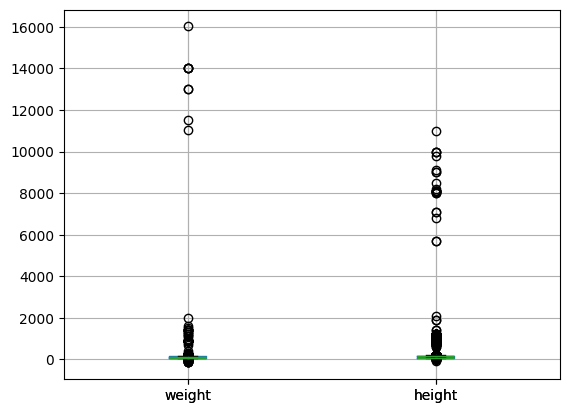

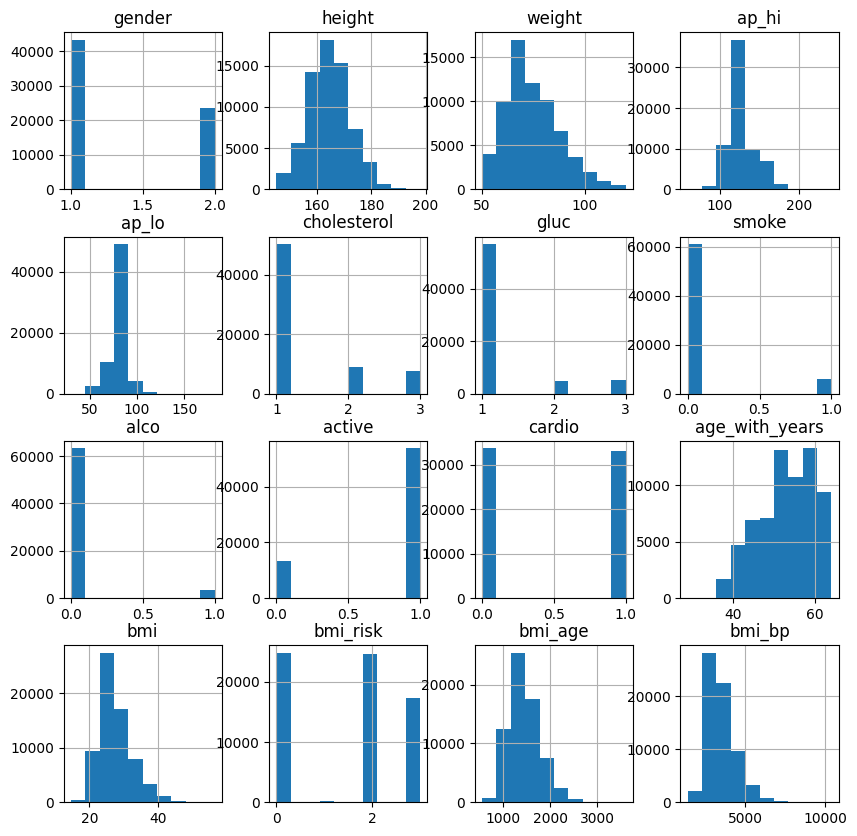

In [28]:
df.hist(figsize=(10,10))
plt.show()

In [29]:
#df['gender']= [1 if i== 2 else 0 for i in df['gender']]
df['gender'] = df['gender'].map({1: 0, 2: 1})

C:\Users\hp\AppData\Local\Temp\ipykernel_19576\1334447821.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gender'] = df['gender'].map({1: 0, 2: 1})


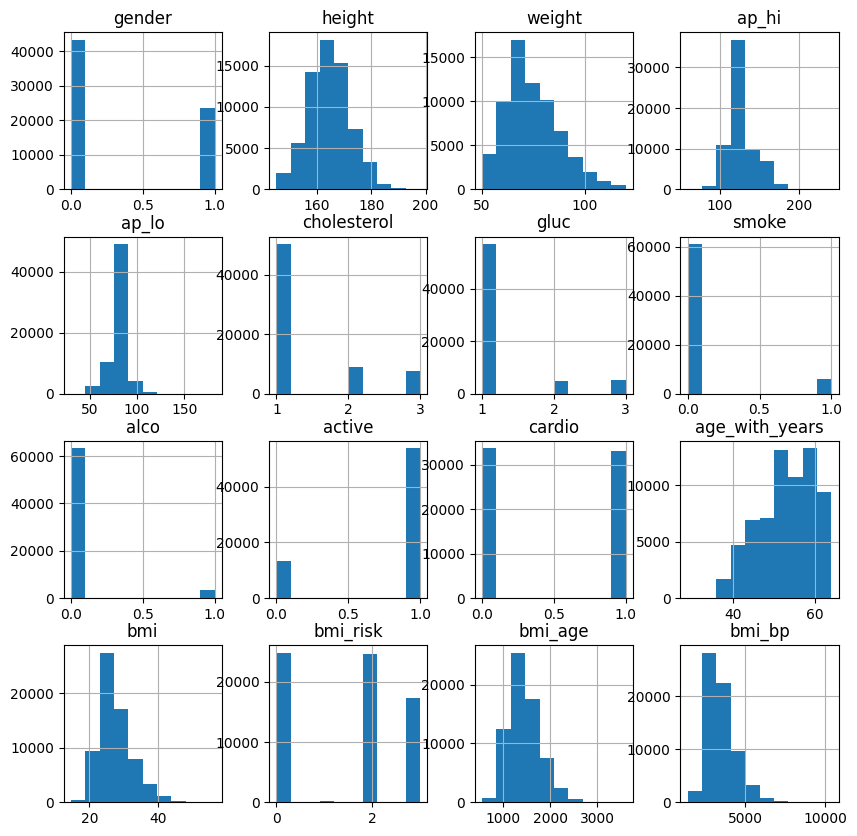

In [30]:
df.hist(figsize=(10,10))
plt.show()

In [31]:
features_to_scale = ['age_with_years', 'height', 'weight']
scaler = RobustScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
df.describe()

C:\Users\hp\AppData\Local\Temp\ipykernel_19576\20304759.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[features_to_scale] = scaler.fit_transform(df[features_to_scale])


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_with_years,bmi,bmi_risk,bmi_age,bmi_bp
count,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000,66929.000000
mean,0.352508,-0.034195,0.125919,126.732313,81.344738,1.364013,1.224731,0.088332,0.053519,0.803224,0.496003,-0.015250,27.406205,1.512752,1451.948002,3493.811967
std,0.477755,0.694569,0.768983,16.560548,9.392196,0.678802,0.570811,0.283780,0.225069,0.397564,0.499988,0.675499,4.836191,1.228067,333.731885,874.553340
min,0.000000,-1.818182,-1.294118,60.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-2.400000,14.577259,0.000000,558.693878,1421.875000
25%,0.000000,-0.545455,-0.411765,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-0.500000,23.875115,0.000000,1216.528926,2865.013774
50%,0.000000,0.000000,0.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,26.370238,2.000000,1410.612245,3305.785124
75%,1.000000,0.454545,0.588235,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.500000,30.110279,3.000000,1644.881093,3954.840454
max,1.000000,3.000000,2.823529,240.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.100000,56.295740,3.000000,3602.927378,10379.155125


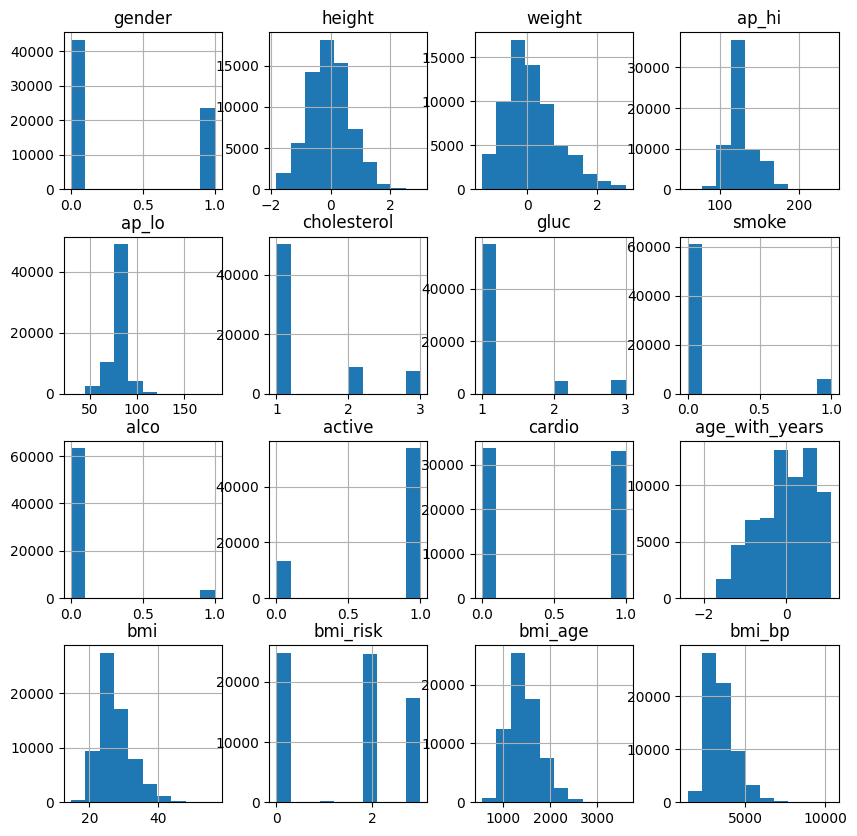

In [32]:
df.hist(figsize=(10,10))
plt.show()

In [33]:
corr = df.corr()
corr['cardio'].sort_values(ascending=False)

cardio            1.000000
ap_hi             0.425638
bmi_bp            0.353973
ap_lo             0.336119
bmi_age           0.272121
age_with_years    0.239001
cholesterol       0.220511
bmi               0.186169
bmi_category      0.175737
weight            0.173630
bmi_risk          0.170049
gluc              0.088299
gender            0.003740
alco             -0.009651
smoke            -0.017204
height           -0.020574
active           -0.037180
Name: cardio, dtype: float64

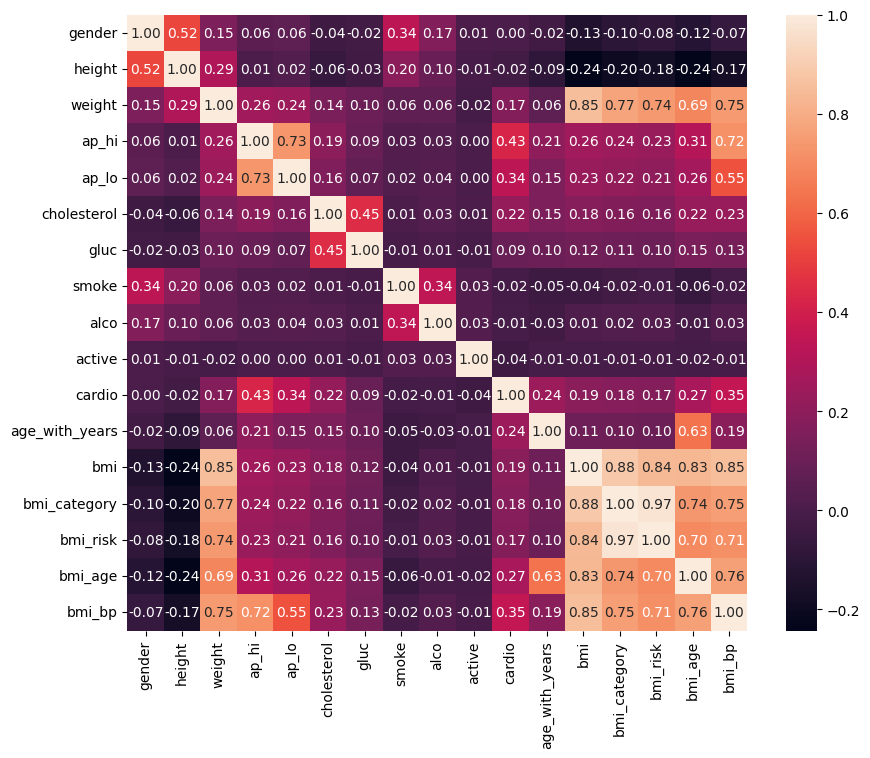

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.show()

In [35]:
important_features = ['ap_hi', 'ap_lo', 'age_with_years', 'cholesterol', 'weight','cardio']
corr = df[important_features].corr()
corr['cardio'].sort_values(ascending=False)

cardio            1.000000
ap_hi             0.425638
ap_lo             0.336119
age_with_years    0.239001
cholesterol       0.220511
weight            0.173630
Name: cardio, dtype: float64

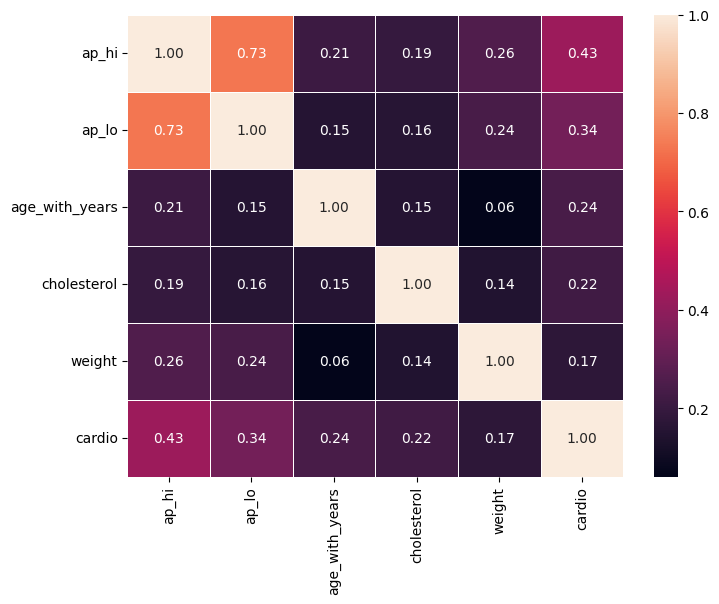

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f",linewidths=0.5)
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_19576\1243454387.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bp_category'] = df.apply(bp_category, axis=1)


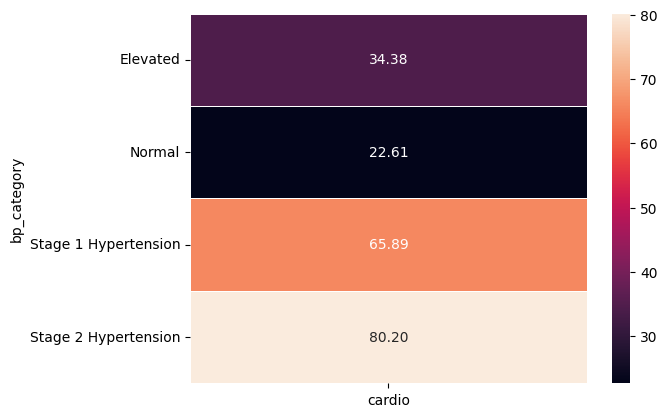

In [37]:
def bp_category(row):
    if row['ap_hi'] < 120 and row['ap_lo'] < 80:
        return 'Normal'
    elif row['ap_hi'] < 130 and row['ap_lo'] < 85:
        return 'Elevated'
    elif (130 <= row['ap_hi'] <= 139) or (80 <= row['ap_lo'] <= 89):
        return 'Stage 1 Hypertension'
    elif row['ap_hi'] >= 140 or row['ap_lo'] >= 90:
        return 'Stage 2 Hypertension'
    else:
        return 'Other'

df['bp_category'] = df.apply(bp_category, axis=1)
# حساب النسب والعدد
bp_prevalence = df.groupby('bp_category')['cardio'].mean() * 100
bp_count = df.groupby('bp_category').size()

sns.heatmap(bp_prevalence.to_frame(), annot=True, fmt=".2f",linewidths=0.5)

plt.show()

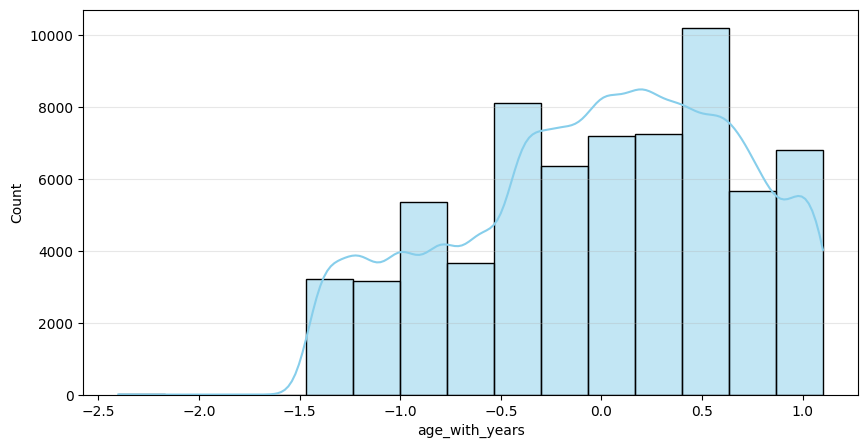

In [38]:
plt.figure(figsize=(10, 5))
sns.histplot(df['age_with_years'], bins=15, kde=True, color='skyblue')
plt.grid(axis='y', alpha=0.3)
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_19576\2236454881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_years'] = df['age_with_years'] / 365.25


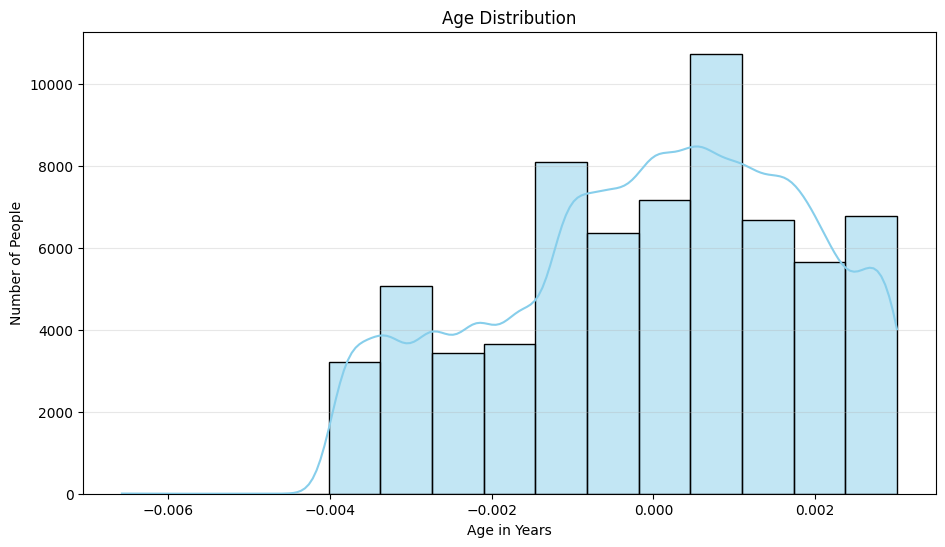

Real Age Statistics:
count    66929.0
mean        -0.0
std          0.0
min         -0.0
25%         -0.0
50%          0.0
75%          0.0
max          0.0
Name: age_years, dtype: float64


In [39]:
# 1. Create real age_with_years (in years) before any Scaling
df['age_years'] = df['age_with_years'] / 365.25

# 2. Distribution of real age (Simple Histogram)
plt.figure(figsize=(11, 6))
sns.histplot(df['age_years'], bins=15, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age in Years')
plt.ylabel('Number of People')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Print statistics of real age to verify
print("Real Age Statistics:")
print(df['age_years'].describe().round(1))

SUPER VIESD

In [40]:


from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

from xgboost import XGBClassifier

In [41]:
# Target
y = df['cardio']
X = df.drop(['cardio', 'bp_category'], axis=1)

In [42]:
from sklearn.model_selection import train_test_split

X_train , X_test ,Y_train ,Y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [43]:
# Optional scaling for Logistic Regression
stand = StandardScaler()
X_train = stand.fit_transform(X_train)
X_test = stand.transform(X_test)
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df.loc[:, ['bmi']] = scaler.fit_transform(df[['bmi']])

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
model = LogisticRegression()
model.fit(X_train , Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [46]:
y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score , confusion_matrix , recall_score , precision_score , f1_score , roc_curve , roc_auc_score

In [48]:
conf= confusion_matrix(Y_test , y_pred)

In [49]:
sns.heatmap(conf , annot = True , cmap="Blues")

<Axes: >

In [50]:
f1_score(Y_test , y_pred)

0.7103868364844553

In [51]:
precision_score(Y_test , y_pred)

0.7455994686150781

In [52]:
recall_score(Y_test , y_pred)

0.6783502039583018

In [53]:
accuracy_score(Y_test , y_pred)

0.7265053040490064

In [54]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.77      0.74      6767
           1       0.75      0.68      0.71      6619

    accuracy                           0.73     13386
   macro avg       0.73      0.73      0.73     13386
weighted avg       0.73      0.73      0.73     13386



logistic

In [55]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [56]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Optional tuning
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1
)

# Convert 'bmi_category' to int to be compatible with XGBoost
X['bmi_category'] = X['bmi_category'].astype(int)
# #  dont delete it pls mohamed ashraaaaaaaf
grid_xgb.fit(X, y)

best_xgb = grid_xgb.best_estimator_

# CV AUC
xgb_auc = cross_val_score(best_xgb, X, y, cv=skf, scoring='roc_auc')
print("XGBoost AUC:", xgb_auc.mean())

XGBoost AUC: 0.8004820695449283


Random Forest AUC: 0.7977144119719746


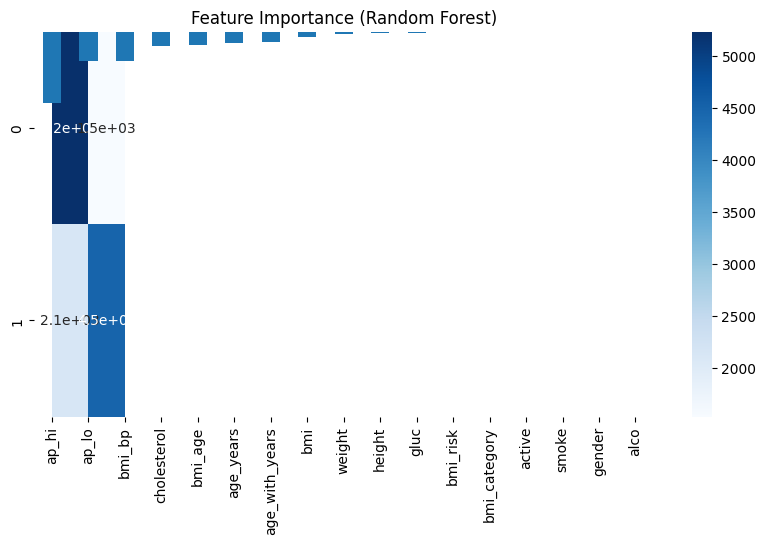

In [57]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf_auc = cross_val_score(rf, X, y, cv=skf, scoring='roc_auc')
print("Random Forest AUC:", rf_auc.mean())

# Fit for feature importance
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance (Random Forest)")
plt.show()

Logistic Regression AUC: 0.7901369496827395


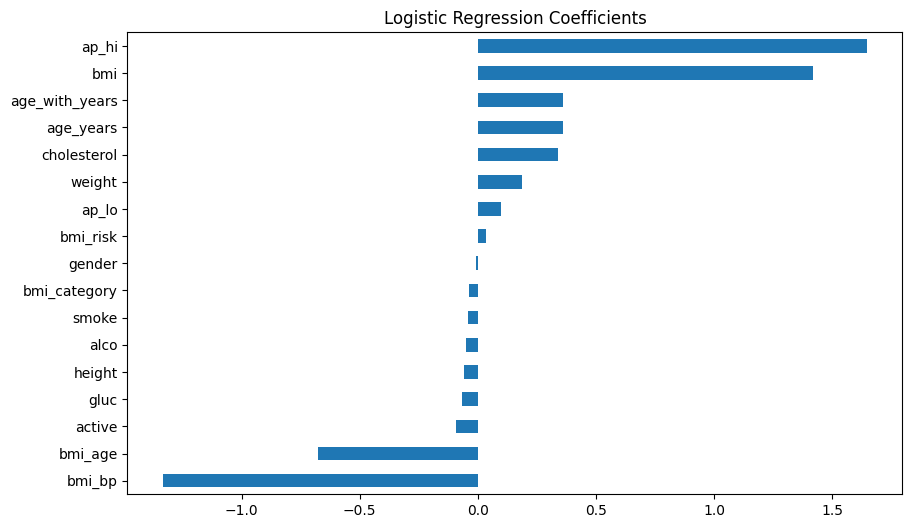

In [58]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        penalty='l2',   # regularization
        C=1.0,
        solver='liblinear',
        max_iter=1000
    ))
])

lr_auc = cross_val_score(lr_pipeline, X, y, cv=skf, scoring='roc_auc')
print("Logistic Regression AUC:", lr_auc.mean())

# Fit for interpretability
lr_pipeline.fit(X, y)

coeffs = pd.Series(
    lr_pipeline.named_steps['lr'].coef_[0],
    index=X.columns
)

coeffs.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Logistic Regression Coefficients")
plt.show()

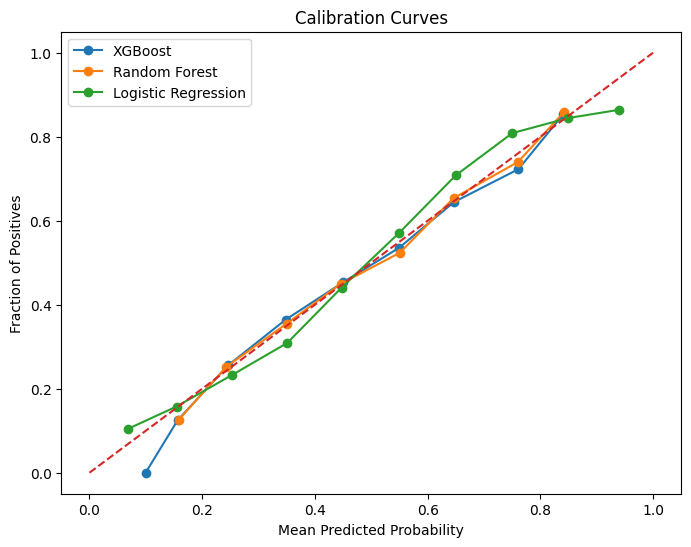

In [59]:
from sklearn.calibration import CalibratedClassifierCV

models = {
    "XGBoost": best_xgb,
    "Random Forest": rf,
    "Logistic Regression": lr_pipeline
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    calibrated = CalibratedClassifierCV(model, cv=skf)
    calibrated.fit(X, y)

    prob_pos = calibrated.predict_proba(X)[:, 1]
    frac_pos, mean_pred = calibration_curve(y, prob_pos, n_bins=10)

    plt.plot(mean_pred, frac_pos, marker='o', label=name)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curves")
plt.legend()
plt.show()

In [60]:
print("=== Final AUC Scores ===")
print(f"XGBoost: {xgb_auc.mean():.4f}")
print(f"Random Forest: {rf_auc.mean():.4f}")
print(f"Logistic Regression: {lr_auc.mean():.4f}")

=== Final AUC Scores ===
XGBoost: 0.8005
Random Forest: 0.7977
Logistic Regression: 0.7901


In [61]:
scale_pos_weight = len(y[y==0]) / len(y[y==1])

In [62]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', best_xgb)
    ],
    final_estimator=LogisticRegression()
)

CHECK OVER FITTING

In [63]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    lr_pipeline, X, y,
    cv=skf,
    scoring='roc_auc',
    return_train_score=True
)

print("Train AUC:", scores['train_score'].mean())
print("Test AUC:", scores['test_score'].mean())

Train AUC: 0.7903359883462051
Test AUC: 0.7901369496827395


In [64]:
models = {
    "XGBoost": best_xgb,
    "Random Forest": rf,
    "Logistic Regression": lr_pipeline
}

In [65]:
for name, model in models.items():
    scores = cross_validate(
        model, X, y,
        cv=skf,
        scoring='roc_auc',
        return_train_score=True
    )

    print(f"{name}")
    print("Train:", scores['train_score'].mean())
    print("Test:", scores['test_score'].mean())
    print("-"*30)

XGBoost
Train: 0.8110551446984651
Test: 0.8004820695449283
------------------------------
Random Forest
Train: 0.8138769994110161
Test: 0.7977144119719746
------------------------------
Logistic Regression
Train: 0.7903359883462051
Test: 0.7901369496827395
------------------------------


## Deep Learning Approach
### DNN Classifier — 5 Hidden Layers (256 → 128 → 64 → 32 → 16)

In [66]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [67]:
# Prepare data for the DNN (Neural Networks need scaled inputs, unlike tree-based models like XGBoost/RF)
y_dl = df['cardio']
X_dl = df.drop(['cardio', 'bp_category'], axis=1)
X_dl['bmi_category'] = X_dl['bmi_category'].astype(int)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl, y_dl, test_size=0.2, random_state=42, stratify=y_dl
)

dl_scaler = StandardScaler()
X_train_dl_scaled = dl_scaler.fit_transform(X_train_dl)
X_test_dl_scaled = dl_scaler.transform(X_test_dl)

print("Train shape:", X_train_dl_scaled.shape)
print("Test shape:", X_test_dl_scaled.shape)

Train shape: (53543, 17)
Test shape: (13386, 17)


In [68]:
# Requirement 1 + 4: DNN classifier with 5 hidden layers (256, 128, 64, 32, 16) + BatchNormalization + Dropout(0.3) regularization
from tensorflow.keras.layers import BatchNormalization, Dropout

n_features = X_train_dl_scaled.shape[1]

dnn_model = Sequential([
    Dense(256, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')  # binary output: cardio risk (0/1)
])

dnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

dnn_model.summary()

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,369 (196.75 KB)

 Trainable params: 49,377 (192.88 KB)

 Non-trainable params: 992 (3.88 KB)

In [69]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)

dnn_history = dnn_model.fit(
    X_train_dl_scaled, y_train_dl,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.6457 - auc: 0.6982 - loss: 0.6674 - val_accuracy: 0.7325 - val_auc: 0.8002 - val_loss: 0.5643
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6986 - auc: 0.7592 - loss: 0.5977 - val_accuracy: 0.7316 - val_auc: 0.8043 - val_loss: 0.5417
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7154 - auc: 0.7728 - loss: 0.5797 - val_accuracy: 0.7347 - val_auc: 0.8055 - val_loss: 0.5381
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7202 - auc: 0.7792 - loss: 0.5708 - val_accuracy: 0.7370 - val_auc: 0.8061 - val_loss: 0.5377
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7262 - auc: 0.7833 - loss: 0.5647 - val_accuracy: 0.7380 - val_auc: 0.8069 - val_loss: 0.5369
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7244 - auc: 0.7835 - loss: 0.5646 - val_accuracy: 0.7373 - val_auc: 0.8075 - val_loss: 0.5364
Epoch 7/100
168/168 ━━━━━━━

419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
DNN Test AUC: 0.7930
              precision    recall  f1-score   support

           0       0.71      0.78      0.75      6747
           1       0.75      0.68      0.72      6639

    accuracy                           0.73     13386
   macro avg       0.73      0.73      0.73     13386
weighted avg       0.73      0.73      0.73     13386



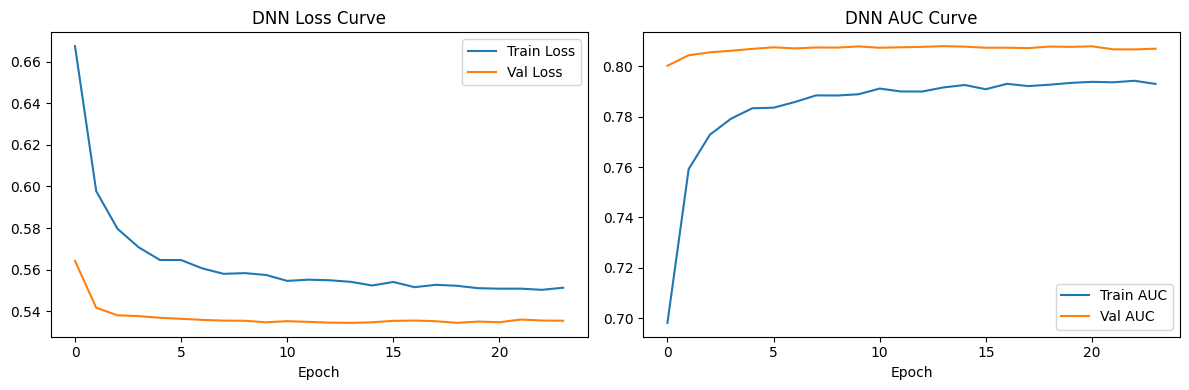

In [70]:
from sklearn.metrics import roc_auc_score, classification_report

dnn_test_proba = dnn_model.predict(X_test_dl_scaled).ravel()
dnn_test_pred = (dnn_test_proba >= 0.5).astype(int)

dnn_test_auc = roc_auc_score(y_test_dl, dnn_test_proba)
print(f"DNN Test AUC: {dnn_test_auc:.4f}")
print(classification_report(y_test_dl, dnn_test_pred))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(dnn_history.history['loss'], label='Train Loss')
plt.plot(dnn_history.history['val_loss'], label='Val Loss')
plt.title('DNN Loss Curve')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(dnn_history.history['auc'], label='Train AUC')
plt.plot(dnn_history.history['val_auc'], label='Val AUC')
plt.title('DNN AUC Curve')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

### 2) Wide & Deep Architecture (Raw Features + Embeddings)

In [71]:
# Requirement 2: Wide & Deep architecture — combine raw (wide) features with learned embeddings (deep) for categorical features
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate
from tensorflow.keras.models import Model

cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi_category', 'bmi_risk']
cont_cols = [c for c in X_dl.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Continuous columns:", cont_cols)

X_train_cat = X_train_dl[cat_cols].astype(int)
X_test_cat = X_test_dl[cat_cols].astype(int)

cont_scaler = StandardScaler()
X_train_cont = cont_scaler.fit_transform(X_train_dl[cont_cols])
X_test_cont = cont_scaler.transform(X_test_dl[cont_cols])

cat_cardinalities = {c: int(X_dl[c].max()) + 1 for c in cat_cols}
print("Cardinalities:", cat_cardinalities)

Categorical columns: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi_category', 'bmi_risk']
Continuous columns: ['height', 'weight', 'ap_hi', 'ap_lo', 'age_with_years', 'bmi', 'bmi_age', 'bmi_bp', 'age_years']
Cardinalities: {'gender': 2, 'cholesterol': 4, 'gluc': 4, 'smoke': 2, 'alco': 2, 'active': 2, 'bmi_category': 4, 'bmi_risk': 4}


In [72]:
# Wide component: raw features fed directly into a linear path
wide_input = Input(shape=(len(cont_cols) + len(cat_cols),), name='wide_input')
wide_output = Dense(1, activation=None, name='wide_linear')(wide_input)

# Deep component: continuous features + categorical embeddings
cont_input = Input(shape=(len(cont_cols),), name='deep_continuous_input')
cat_inputs = []
cat_embeddings = []

for col in cat_cols:
    cat_in = Input(shape=(1,), name=f'cat_{col}')
    emb_dim = min(8, cat_cardinalities[col])
    emb = Embedding(input_dim=cat_cardinalities[col], output_dim=emb_dim, name=f'emb_{col}')(cat_in)
    emb = Flatten()(emb)
    cat_inputs.append(cat_in)
    cat_embeddings.append(emb)

deep_concat = Concatenate(name='deep_concat')([cont_input] + cat_embeddings)

# Deep path with BatchNorm + Dropout(0.3) — Requirement 4
deep = Dense(128, activation='relu')(deep_concat)
deep = BatchNormalization()(deep)
deep = Dropout(0.3)(deep)

deep = Dense(64, activation='relu')(deep)
deep = BatchNormalization()(deep)
deep = Dropout(0.3)(deep)

deep = Dense(32, activation='relu')(deep)
deep = BatchNormalization()(deep)
deep = Dropout(0.3)(deep)

deep_output = Dense(1, activation=None, name='deep_linear')(deep)

combined = tf.keras.layers.Add(name='wide_deep_add')([wide_output, deep_output])
final_output = tf.keras.layers.Activation('sigmoid', name='final_output')(combined)

wide_deep_model = Model(
    inputs=[wide_input, cont_input] + cat_inputs,
    outputs=final_output
)

wide_deep_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

wide_deep_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cat_gender          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_cholesterol     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_gluc            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_smoke           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_alco            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_active          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_bmi_category    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_bmi_risk        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_gender          │ (None, 1, 2)      │          4 │ cat_gender[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_cholesterol     │ (None, 1, 4)      │         16 │ cat_cholesterol[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_gluc            │ (None, 1, 4)      │         16 │ cat_gluc[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_smoke           │ (None, 1, 2)      │          4 │ cat_smoke[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_alco            │ (None, 1, 2)      │          4 │ cat_alco[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_active          │ (None, 1, 2)      │          4 │ cat_active[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_bmi_category    │ (None, 1, 4)      │         16 │ cat_bmi_category… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_bmi_risk        │ (None, 1, 4)      │         16 │ cat_bmi_risk[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_continuous_in… │ (None, 9)         │          0 │ -               

 Total params: 15,715 (61.39 KB)

 Trainable params: 15,267 (59.64 KB)

 Non-trainable params: 448 (1.75 KB)

In [73]:
X_train_wide = np.concatenate([X_train_cont, X_train_cat.values], axis=1)
X_test_wide = np.concatenate([X_test_cont, X_test_cat.values], axis=1)

train_inputs = [X_train_wide, X_train_cont] + [X_train_cat[col].values for col in cat_cols]
test_inputs = [X_test_wide, X_test_cont] + [X_test_cat[col].values for col in cat_cols]

wd_early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)

wide_deep_history = wide_deep_model.fit(
    train_inputs, y_train_dl,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[wd_early_stop],
    verbose=1
)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.6658 - auc: 0.7199 - loss: 0.6719 - val_accuracy: 0.6850 - val_auc: 0.7380 - val_loss: 0.6093
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7040 - auc: 0.7628 - loss: 0.5950 - val_accuracy: 0.7267 - val_auc: 0.7916 - val_loss: 0.5601
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7174 - auc: 0.7777 - loss: 0.5739 - val_accuracy: 0.7351 - val_auc: 0.8028 - val_loss: 0.5423
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7234 - auc: 0.7840 - loss: 0.5655 - val_accuracy: 0.7364 - val_auc: 0.8050 - val_loss: 0.5394
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7274 - auc: 0.7876 - loss: 0.5600 - val_accuracy: 0.7349 - val_auc: 0.8058 - val_loss: 0.5386
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7276 - auc: 0.7890 - loss: 0.5580 - val_accuracy: 0.7352 - val_auc: 0.8058 - val_loss: 0.5388
Epoch 7/100
168/168 ━━━━━━━

In [74]:
wd_test_proba = wide_deep_model.predict(test_inputs).ravel()
wd_test_pred = (wd_test_proba >= 0.5).astype(int)

wd_test_auc = roc_auc_score(y_test_dl, wd_test_proba)
print(f"Wide & Deep Test AUC: {wd_test_auc:.4f}")
print(classification_report(y_test_dl, wd_test_pred))

419/419 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
Wide & Deep Test AUC: 0.7945
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6747
           1       0.75      0.68      0.72      6639

    accuracy                           0.73     13386
   macro avg       0.74      0.73      0.73     13386
weighted avg       0.73      0.73      0.73     13386



### 3) Autoencoder for Unsupervised Feature Learning (12 → 8 → 4 → 8 → 12)

In [75]:
# Requirement 3: Autoencoder (12 -> 8 -> 4 -> 8 -> 12) for unsupervised feature learning
ae_features = ['age_with_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
               'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
print(f"Number of input features for the Autoencoder: {len(ae_features)}")

ae_scaler = StandardScaler()
X_ae = ae_scaler.fit_transform(df[ae_features])

X_train_ae, X_test_ae = train_test_split(X_ae, test_size=0.2, random_state=42)

Number of input features for the Autoencoder: 12


In [76]:
ae_input = Input(shape=(12,), name='ae_input')

# Encoder: 12 -> 8 -> 4 (bottleneck)
encoded = Dense(8, activation='relu')(ae_input)
encoded = Dense(4, activation='relu', name='bottleneck')(encoded)

# Decoder: 4 -> 8 -> 12
decoded = Dense(8, activation='relu')(encoded)
decoded = Dense(12, activation='linear')(decoded)

autoencoder = Model(inputs=ae_input, outputs=decoded, name='autoencoder')
encoder = Model(inputs=ae_input, outputs=encoded, name='encoder')

autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 12)             │           108 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288 (1.12 KB)

 Trainable params: 288 (1.12 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
ae_early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

ae_history = autoencoder.fit(
    X_train_ae, X_train_ae,
    validation_data=(X_test_ae, X_test_ae),
    epochs=100,
    batch_size=256,
    callbacks=[ae_early_stop],
    verbose=1
)

reconstruction_mse = autoencoder.evaluate(X_test_ae, X_test_ae, verbose=0)
print(f"Autoencoder Test Reconstruction MSE: {reconstruction_mse:.4f}")

# Extract the 4-dimensional latent representation for the full dataset
latent_features = encoder.predict(X_ae)
latent_df = pd.DataFrame(latent_features, columns=[f'latent_{i+1}' for i in range(4)], index=df.index)

df = pd.concat([df, latent_df], axis=1)
print("Latent features added to df:", list(latent_df.columns))
df[latent_df.columns].describe()

Epoch 1/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.9159 - val_loss: 0.8068
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7011 - val_loss: 0.6278
Epoch 3/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.5910 - val_loss: 0.5650
Epoch 4/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5244 - val_loss: 0.4733
Epoch 5/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4362 - val_loss: 0.4108
Epoch 6/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3946 - val_loss: 0.3843
Epoch 7/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3761 - val_loss: 0.3720
Epoch 8/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3673 - val_loss: 0.3658
Epoch 9/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3626 - val_loss: 0.3624
Epoch 10/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3597 - val_loss: 0.3595
Epoch 11/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3574 - val_loss: 0.3576
Epoch 12/100
210/210 ━━━━━━━━━━━━━━━━━━━

,latent_1,latent_2,latent_3,latent_4
count,66929.000000,66929.000000,66929.000000,66929.000000
mean,8.121696,5.307106,3.998686,4.811714
std,2.882615,1.631584,1.316024,2.169692
min,0.000000,0.000000,0.000000,0.000000
25%,6.907244,4.476541,3.164486,3.466822
50%,8.417843,5.549050,3.830232,4.288844
75%,9.976593,6.357267,4.825539,5.754184
max,17.245680,10.397475,9.675393,13.821692


### 4) Statistical Comparison: Deep Learning vs Ensemble Methods

In [78]:
# Requirement 5: Compare DL performance against ensemble methods (XGBoost, Random Forest) using statistical tests
from scipy import stats

def build_dnn():
    m = Sequential([
        Dense(256, activation='relu', input_shape=(X_dl.shape[1],)),
        BatchNormalization(), Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(), Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(), Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(), Dropout(0.3),
        Dense(16, activation='relu'),
        BatchNormalization(), Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=[AUC(name='auc')])
    return m

# Use the SAME StratifiedKFold (skf) splits used earlier for XGBoost/Random Forest for a fair, paired comparison
dnn_cv_auc = []
X_dl_values = X_dl.values
y_dl_values = y_dl.values

for fold, (train_idx, val_idx) in enumerate(skf.split(X_dl_values, y_dl_values)):
    fold_scaler = StandardScaler()
    X_tr = fold_scaler.fit_transform(X_dl_values[train_idx])
    X_val = fold_scaler.transform(X_dl_values[val_idx])
    y_tr, y_val = y_dl_values[train_idx], y_dl_values[val_idx]

    fold_model = build_dnn()
    fold_es = EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)
    fold_model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                   epochs=60, batch_size=256, callbacks=[fold_es], verbose=0)

    val_proba = fold_model.predict(X_val, verbose=0).ravel()
    fold_auc = roc_auc_score(y_val, val_proba)
    dnn_cv_auc.append(fold_auc)
    print(f"Fold {fold+1}: DNN AUC = {fold_auc:.4f}")

dnn_cv_auc = np.array(dnn_cv_auc)
print(f"\nDNN Mean CV AUC: {dnn_cv_auc.mean():.4f} (+/- {dnn_cv_auc.std():.4f})")

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: DNN AUC = 0.8034


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: DNN AUC = 0.7933


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3: DNN AUC = 0.8025


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: DNN AUC = 0.8013


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: DNN AUC = 0.7987

DNN Mean CV AUC: 0.7998 (+/- 0.0036)


In [79]:
print("=== Mean AUC per model ===")
print(f"XGBoost:             {xgb_auc.mean():.4f}")
print(f"Random Forest:       {rf_auc.mean():.4f}")
print(f"DNN (Deep Learning): {dnn_cv_auc.mean():.4f}")
print(f"Wide & Deep (single test split, for reference): {wd_test_auc:.4f}")

t_xgb, p_xgb = stats.ttest_rel(dnn_cv_auc, xgb_auc)
t_rf, p_rf = stats.ttest_rel(dnn_cv_auc, rf_auc)

print("\n=== Paired t-test: DNN vs XGBoost ===")
print(f"t-statistic = {t_xgb:.4f}, p-value = {p_xgb:.4f}")
print("Statistically significant difference" if p_xgb < 0.05 else "No statistically significant difference", "(alpha=0.05)")

print("\n=== Paired t-test: DNN vs Random Forest ===")
print(f"t-statistic = {t_rf:.4f}, p-value = {p_rf:.4f}")
print("Statistically significant difference" if p_rf < 0.05 else "No statistically significant difference", "(alpha=0.05)")

=== Mean AUC per model ===
XGBoost:             0.8005
Random Forest:       0.7977
DNN (Deep Learning): 0.7998
Wide & Deep (single test split, for reference): 0.7945

=== Paired t-test: DNN vs XGBoost ===
t-statistic = -1.3017, p-value = 0.2629
No statistically significant difference (alpha=0.05)

=== Paired t-test: DNN vs Random Forest ===
t-statistic = 3.7597, p-value = 0.0198
Statistically significant difference (alpha=0.05)


Unsupervised

In [80]:

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


features = ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
X = df[features]


scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42, n_init=10)
df['cluster_id'] = kmeans.fit_predict(X_scaled)

cluster_analysis = df.groupby('cluster_id')[features].mean()


print(cluster_analysis)

              gender    height    weight       ap_hi      ap_lo  cholesterol  \
cluster_id                                                                     
0           0.251300 -0.208881  0.304463  130.253433  82.832689     2.805626   
1           0.762699  0.659491  0.612246  122.645975  79.917957     1.125622   
2           0.157770 -0.311104 -0.281273  120.929891  80.241056     1.083698   
3           0.575954  0.330617  1.084144  155.620230  96.563355     1.651188   
4           0.229749 -0.355730 -0.016962  143.868318  90.753598     1.205798   
5           0.222329 -0.236238 -0.286189  109.252011  67.419092     1.170433   

                gluc     smoke      alco    active  
cluster_id                                          
0           2.078390  0.067191  0.051193  0.810292  
1           1.115673  0.185105  0.092132  0.797310  
2           1.076183  0.033664  0.026407  0.798219  
3           1.300036  0.151728  0.099712  0.801476  
4           1.099301  0.057669  0.040810 

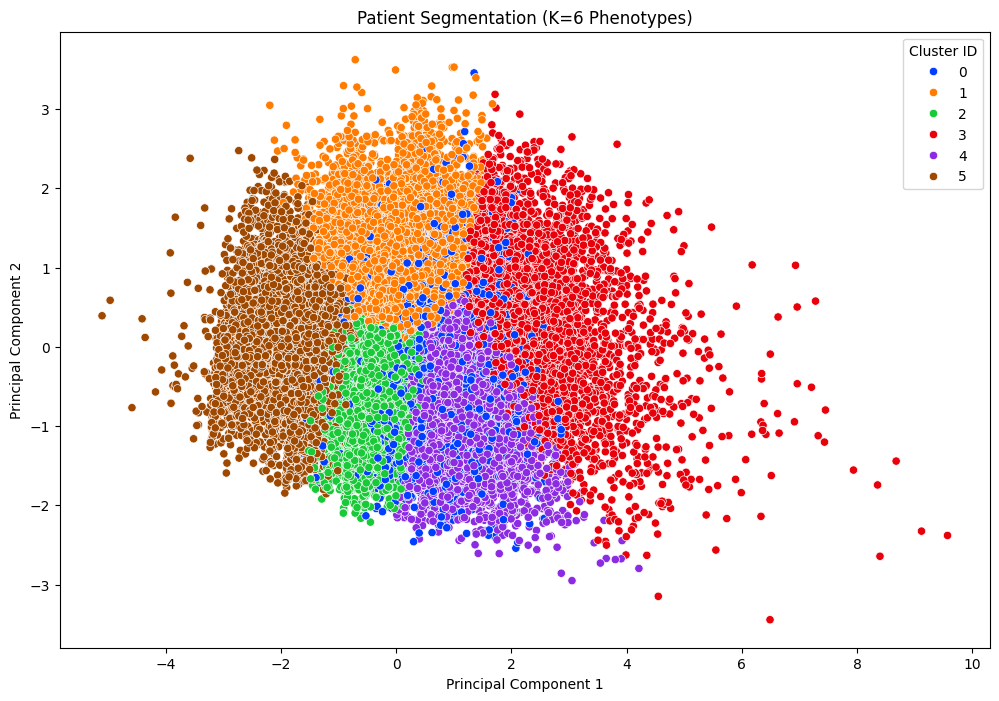

In [81]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster_id'], palette='bright')
plt.title('Patient Segmentation (K=6 Phenotypes)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster ID')
plt.show()

In [82]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=10) 
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)


outliers = df[df['dbscan_cluster'] == -1]

print(f"Unique Risk Profiles (Outliers): {len(outliers)}")

Unique Risk Profiles (Outliers): 112


In [83]:

outlier_analysis = outliers[features].mean()
normal_analysis = df[df['dbscan_cluster'] != -1][features].mean()

comparison = pd.DataFrame({
    'Normal Patients': normal_analysis,
    'Unique Risk Profiles (Outliers)': outlier_analysis
})

print(comparison)

             Normal Patients  Unique Risk Profiles (Outliers)
gender              0.352231                         0.517857
height             -0.034580                         0.195617
weight              0.124556                         0.938603
ap_hi             126.648622                       176.660714
ap_lo              81.314650                        99.294643
cholesterol         1.362962                         1.991071
gluc                1.223985                         1.669643
smoke               0.087957                         0.312500
alco                0.053145                         0.276786
active              0.803358                         0.723214


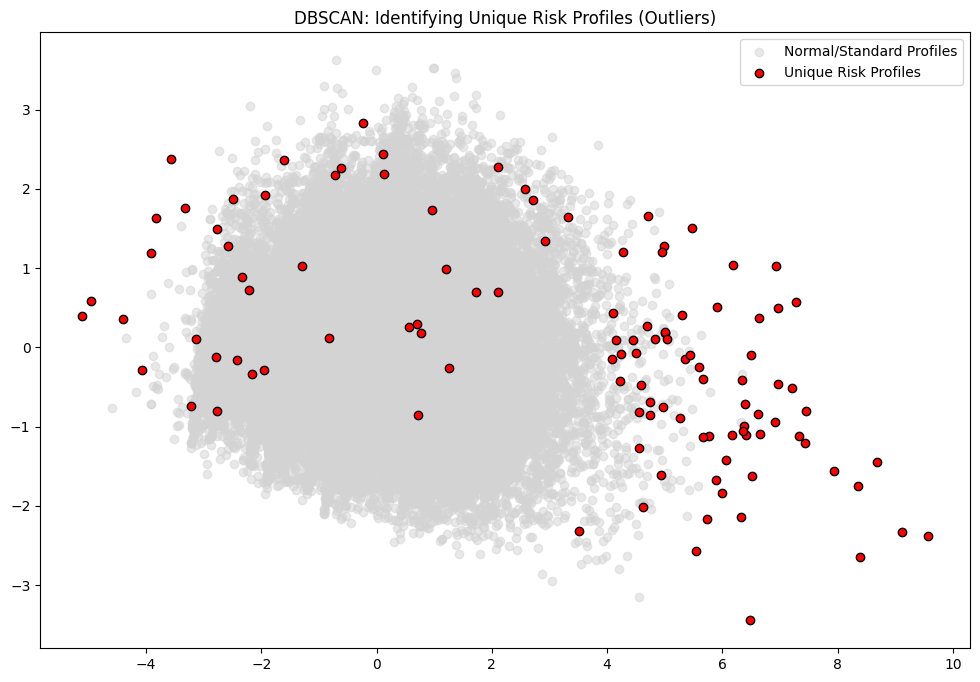

In [84]:
plt.figure(figsize=(12, 8))

plt.scatter(X_pca[df['dbscan_cluster'] != -1, 0], 
            X_pca[df['dbscan_cluster'] != -1, 1], 
            c='lightgrey', label='Normal/Standard Profiles', alpha=0.5)


plt.scatter(X_pca[df['dbscan_cluster'] == -1, 0], 
            X_pca[df['dbscan_cluster'] == -1, 1], 
            c='red', label='Unique Risk Profiles', edgecolors='black')

plt.title('DBSCAN: Identifying Unique Risk Profiles (Outliers)')
plt.legend()
plt.show()

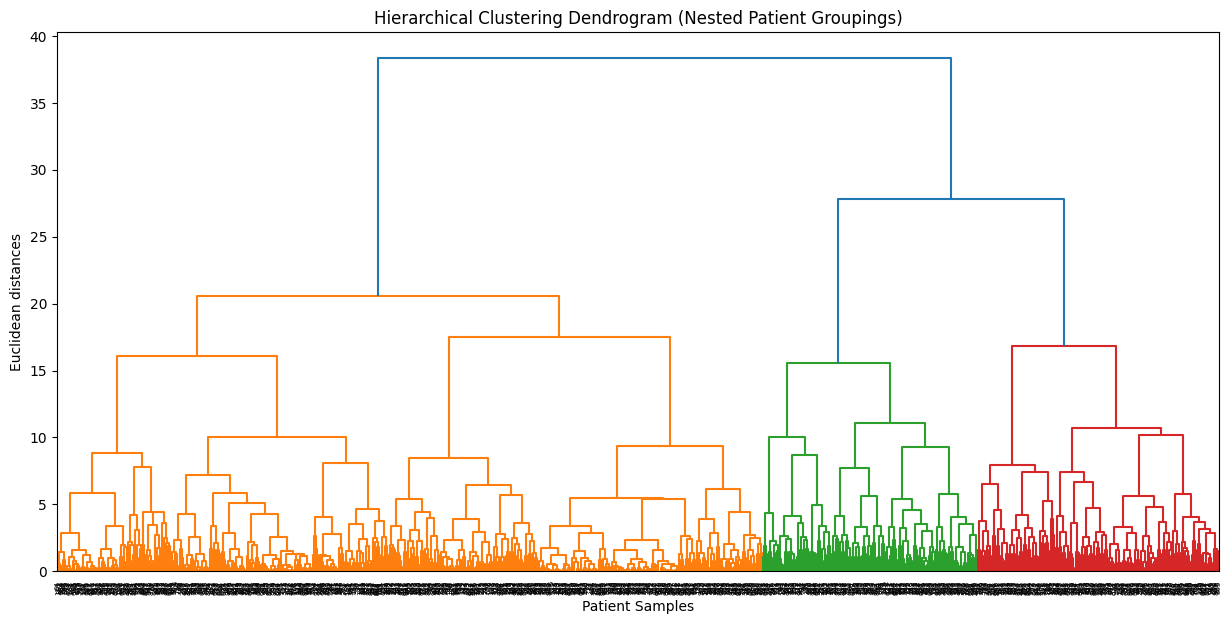

Dendrogram generated. This tree shows how patients are nested into sub-groups.

--- Hierarchical Cluster Profiles (Sample) ---
                        gender    height    weight       ap_hi      ap_lo  \
hierarchical_cluster                                                        
0                     0.109034 -0.250071 -0.305479  116.246106  75.551402   
1                     0.389423  0.014423  0.523049  150.798077  92.427885   
2                     0.291892 -0.112531  0.188235  129.302703  82.286486   
3                     0.678322  0.235219  0.389284  122.870629  80.241259   

                      cholesterol      gluc     smoke      alco    active  
hierarchical_cluster                                                       
0                        1.052960  1.046729  0.028037  0.018692  0.760125  
1                        1.375000  1.173077  0.076923  0.033654  0.836538  
2                        2.497297  1.789189  0.091892  0.021622  0.816216  
3                        1.097

In [85]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt


df_sample = df.sample(n=1000, random_state=42)
X_sample_scaled = scaler.transform(df_sample[features])

# Step 1: Create the Dendrogram to visualize nested groupings
plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram (Nested Patient Groupings)')
plt.xlabel('Patient Samples')
plt.ylabel('Euclidean distances')

# Using 'ward' linkage to minimize variance within clusters
dendrogram = sch.dendrogram(sch.linkage(X_sample_scaled, method='ward'))
plt.show()

print("Dendrogram generated. This tree shows how patients are nested into sub-groups.")

# Step 2: Apply Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering


hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df_sample['hierarchical_cluster'] = hc.fit_predict(X_sample_scaled)


# Step 3: Analyze the hierarchy
print("\n--- Hierarchical Cluster Profiles (Sample) ---")
print(df_sample.groupby('hierarchical_cluster')[features].mean())

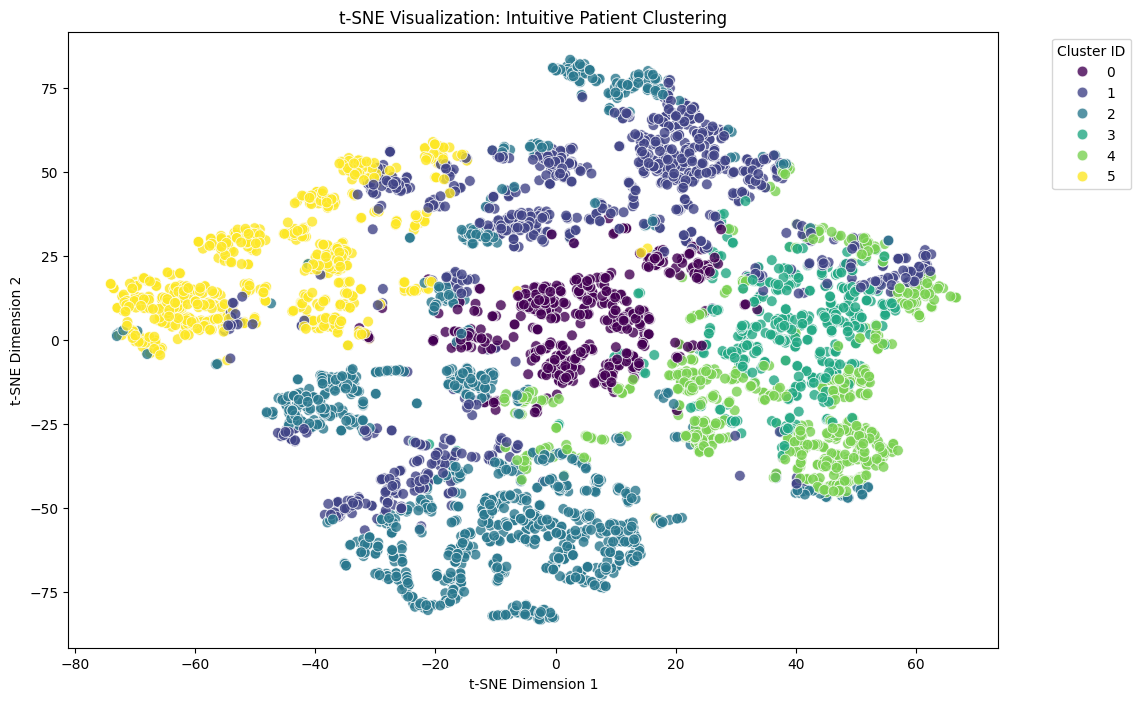

t-SNE visualization generated. The 'learning_rate' was set to 'auto' for best results.


In [86]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns


df_tsne_sample = df.sample(n=5000, random_state=42)
X_tsne_scaled = scaler.transform(df_tsne_sample[features])

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_tsne_scaled)


tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['cluster'] = df_tsne_sample['cluster_id'].values

# visualization
plt.figure(figsize=(12, 8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='cluster', data=tsne_df, palette='viridis', s=60, alpha=0.8)

plt.title('t-SNE Visualization: Intuitive Patient Clustering')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("t-SNE visualization generated. The 'learning_rate' was set to 'auto' for best results.")

--- Final Clinical Profiles per Cluster ---
           age_with_years       gender       height       weight        \
                     mean   std   mean   std   mean   std   mean   std   
cluster_id                                                               
0                    0.25  0.59   0.25  0.43  -0.21  0.64   0.30  0.77   
1                   -0.10  0.69   0.76  0.43   0.66  0.53   0.61  0.68   
2                   -0.04  0.66   0.16  0.36  -0.31  0.51  -0.28  0.50   
3                    0.11  0.64   0.58  0.49   0.33  0.69   1.08  0.74   
4                    0.13  0.63   0.23  0.42  -0.36  0.57  -0.02  0.59   
5                   -0.26  0.70   0.22  0.42  -0.24  0.59  -0.29  0.58   

             ap_hi         ... cholesterol        gluc       smoke        \
              mean    std  ...        mean   std  mean   std  mean   std   
cluster_id                 ...                                             
0           130.25  11.93  ...        2.81  0.43  2.08  0.91 

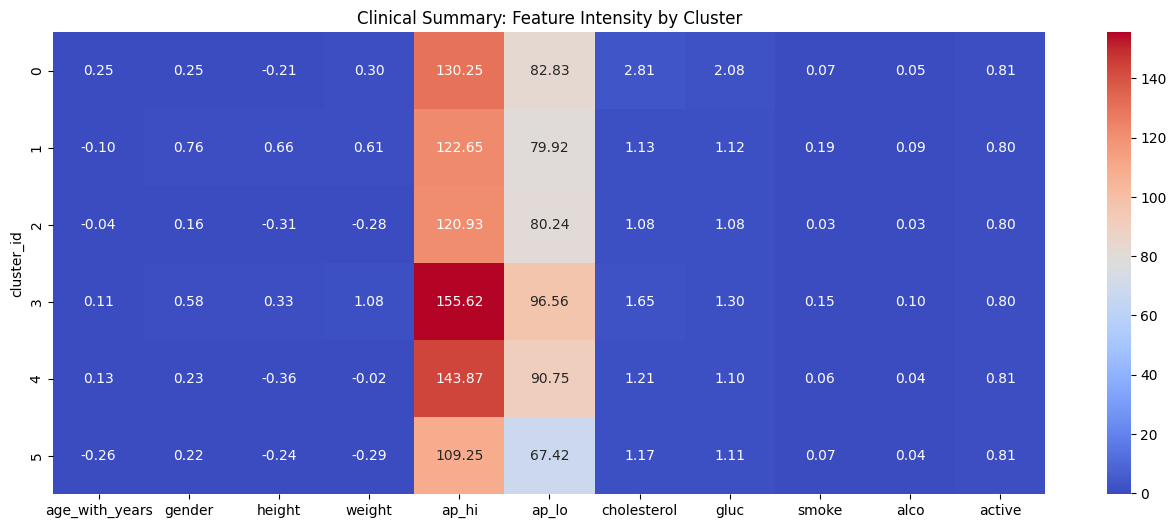


Analysis complete. You can now present these profiles as your final strategy.


In [87]:

final_features = ['age_with_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


cluster_summary = df.groupby('cluster_id')[final_features].agg(['mean', 'std']).round(2)

print("--- Final Clinical Profiles per Cluster ---")
print(cluster_summary)


cvd_risk = (df.groupby('cluster_id')['cardio'].mean() * 100).round(2)
print("\n--- Cardiovascular Disease (CVD) Prevalence per Cluster (%) ---")
print(cvd_risk)


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
sns.heatmap(df.groupby('cluster_id')[final_features].mean(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Clinical Summary: Feature Intensity by Cluster')
plt.show()

print("\nAnalysis complete. You can now present these profiles as your final strategy.")

In [88]:
import joblib
from xgboost import XGBClassifier


features = ['age_with_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
X = df[features]
y = df['cardio']


final_model = XGBClassifier(n_estimators=100, random_state=42)
final_model.fit(X, y)


joblib.dump(final_model, 'risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl') 


df.to_csv('customer_data.csv', index=False)

print("All resources (Model, Scaler, Data) saved successfully!")

All resources (Model, Scaler, Data) saved successfully!


Streamlit

In [ ]:

import streamlit as st
import pandas as pd
import joblib
import numpy as np


@st.cache_resource
def load_resources():
    # Loading the names we just saved
    model = joblib.load('risk_model.pkl')
    scaler = joblib.load('scaler.pkl')
    return model, scaler

@st.cache_data
def load_data():
    # Loading the 70k records
    return pd.read_csv('customer_data.csv')

model, scaler = load_resources()
df = load_data()

# Now the rest of the code for Lookup and Scoring...


"\nimport streamlit as st\nimport pandas as pd\nimport joblib\nimport numpy as np\n\n\n@st.cache_resource\ndef load_resources():\n    # Loading the names we just saved\n    model = joblib.load('risk_model.pkl')\n    scaler = joblib.load('scaler.pkl')\n    return model, scaler\n\n@st.cache_data\ndef load_data():\n    # Loading the 70k records\n    return pd.read_csv('customer_data.csv')\n\nmodel, scaler = load_resources()\ndf = load_data()\n\n# Now the rest of the code for Lookup and Scoring...\n"

In [ ]:

st.divider()
st.header("Interactive Segment Explorer")
st.markdown("Filter customers by demographics and health metrics to analyze specific segments.")

# 1. Layout for Filters
col_f1, col_f2, col_f3 = st.columns(3)

with col_f1:
    # Filter by Age (using your preprocessed column)
    age_range = st.slider("Select Age Range", 
                          int(df['age_with_years'].min()), 
                          int(df['age_with_years'].max()), 
                          (30, 60))

with col_f2:
    # Filter by Gender
    gender_filter = st.multiselect("Select Gender", 
                                   options=[1, 2], 
                                   default=[1, 2],
                                   format_func=lambda x: "Female" if x==1 else "Male")

with col_f3:
    # Filter by Cholesterol Level
    chol_filter = st.multiselect("Cholesterol Level", 
                                 options=[1, 2, 3], 
                                 default=[1, 2, 3])

# 2. Applying Filters to the Dataframe
filtered_df = df[
    (df['age_with_years'] >= age_range[0]) & 
    (df['age_with_years'] <= age_range[1]) & 
    (df['gender'].isin(gender_filter)) & 
    (df['cholesterol'].isin(chol_filter))
]

# 3. Displaying Segment Metrics
st.subheader(f"Results for this Segment ({len(filtered_df):,} customers)")

m1, m2, m3 = st.columns(3)
with m1:
    avg_weight = filtered_df['weight'].mean()
    st.metric("Avg. Weight", f"{avg_weight:.1f} kg")
with m2:
    # Prevalence of CVD in this specific segment
    cvd_rate = (filtered_df['cardio'].mean() * 100)
    st.metric("CVD Prevalence", f"{cvd_rate:.1f}%")
with m3:
    avg_active = (filtered_df['active'].mean() * 100)
    st.metric("Active Lifestyle", f"{avg_active:.1f}%")

# 4. Segment Visualization
st.write("### Distribution of Clusters in this Segment")
# Displaying the K-Means clusters distribution for this filtered segment
if 'cluster_id' in filtered_df.columns:
    cluster_counts = filtered_df['cluster_id'].value_counts().sort_index()
    st.bar_chart(cluster_counts)
    st.caption("This chart shows how many customers fall into each clinical phenotype within your filters.")
else:
    st.warning("Please run the Clustering step in your notebook to see Cluster IDs.")


'\nst.divider()\nst.header("Interactive Segment Explorer")\nst.markdown("Filter customers by demographics and health metrics to analyze specific segments.")\n\n# 1. Layout for Filters\ncol_f1, col_f2, col_f3 = st.columns(3)\n\nwith col_f1:\n    # Filter by Age (using your preprocessed column)\n    age_range = st.slider("Select Age Range", \n                          int(df[\'age_with_years\'].min()), \n                          int(df[\'age_with_years\'].max()), \n                          (30, 60))\n\nwith col_f2:\n    # Filter by Gender\n    gender_filter = st.multiselect("Select Gender", \n                                   options=[1, 2], \n                                   default=[1, 2],\n                                   format_func=lambda x: "Female" if x==1 else "Male")\n\nwith col_f3:\n    # Filter by Cholesterol Level\n    chol_filter = st.multiselect("Cholesterol Level", \n                                 options=[1, 2, 3], \n                                 default=[1, 2

In [ ]:

# --- Requirement: Campaign Performance Simulator ---
st.divider()
st.header("Campaign Performance Simulator")
st.markdown("Estimate the potential ROI of targeting specific patient segments.")

# 1. Simulator Inputs
col_s1, col_s2 = st.columns(2)

with col_s1:
    st.subheader("Campaign Budgeting")
    total_budget = st.number_input("Total Marketing Budget ($)", min_value=1000, value=10000, step=500)
    cost_per_reach = st.slider("Cost per Contact ($)", 0.5, 5.0, 1.5)
    
with col_s2:
    st.subheader("Expected Conversion")
    # Conversion here means: Customer starts a prevention program
    expected_conv_rate = st.slider("Target Conversion Rate (%)", 1.0, 20.0, 5.0) / 100
    prevention_program_value = st.number_input("Value per Program Enrolment ($)", min_value=50, value=250)

# 2. Simulation Logic
# We use the filtered_df from the previous step (Explorer) to target specific people
target_audience_size = len(filtered_df)
potential_reach = int(total_budget / cost_per_reach)

# Limit reach to target audience size
actual_reach = min(potential_reach, target_audience_size)
expected_conversions = int(actual_reach * expected_conv_rate)
total_revenue = expected_conversions * prevention_program_value
roi = ((total_revenue - total_budget) / total_budget) * 100

# 3. Displaying Results
st.write(f"### Simulation Results for Selected Segment")

r1, r2, r3, r4 = st.columns(4)
with r1:
    st.metric("Potential Reach", f"{actual_reach:,}")
with r2:
    st.metric("Expected Enrolments", f"{expected_conversions:,}")
with r3:
    st.metric("Projected Revenue", f"${total_revenue:,.0f}")
with r4:
    # Color coding for ROI
    st.metric("Projected ROI", f"{roi:.1f}%", delta=f"{roi:.1f}%", delta_color="normal")

# 4. Strategic Recommendation based on Cluster Risk
st.info("trategic Insight:** This segment has a CVD prevalence of " + 
        f"{filtered_df['cardio'].mean()*100:.1f}%. " +
        "High-risk segments usually have higher conversion rates for health programs.")

# Plotting the ROI Projection
labels = ['Budget', 'Expected Revenue']
values = [total_budget, total_revenue]
fig_sim, ax_sim = plt.subplots(figsize=(6, 4))
sns.barplot(x=labels, y=values, palette=['#FF9999','#66b3ff'], ax=ax_sim)
plt.title("Cost vs. Projected Revenue")
st.pyplot(fig_sim)


'\n# --- Requirement: Campaign Performance Simulator ---\nst.divider()\nst.header("Campaign Performance Simulator")\nst.markdown("Estimate the potential ROI of targeting specific patient segments.")\n\n# 1. Simulator Inputs\ncol_s1, col_s2 = st.columns(2)\n\nwith col_s1:\n    st.subheader("Campaign Budgeting")\n    total_budget = st.number_input("Total Marketing Budget ($)", min_value=1000, value=10000, step=500)\n    cost_per_reach = st.slider("Cost per Contact ($)", 0.5, 5.0, 1.5)\n\nwith col_s2:\n    st.subheader("Expected Conversion")\n    # Conversion here means: Customer starts a prevention program\n    expected_conv_rate = st.slider("Target Conversion Rate (%)", 1.0, 20.0, 5.0) / 100\n    prevention_program_value = st.number_input("Value per Program Enrolment ($)", min_value=50, value=250)\n\n# 2. Simulation Logic\n# We use the filtered_df from the previous step (Explorer) to target specific people\ntarget_audience_size = len(filtered_df)\npotential_reach = int(total_budget / co

In [ ]:

# --- Requirement: Customer Lifetime Value (CLV) Forecasting ---
st.divider()
st.header("Customer Lifetime Value (CLV) Projection")
st.markdown("Forecasting the long-term economic value of patient prevention programs.")

# 1. CLV Logic setup
# We define CLV as: (Cost Saved by Prevention * Probability of staying healthy)
# Patients in low-risk clusters have higher "Retention" in health programs.

st.subheader("Financial Assumptions")
c1, c2 = st.columns(2)
with c1:
    annual_treatment_cost = st.number_input("Avg. Annual Treatment Cost ($)", value=5000)
with c2:
    years_projection = st.slider("Projection Period (Years)", 1, 10, 5)

# 2. Calculating CLV per Cluster
# We assume that preventing CVD in a high-risk patient saves the 'annual_treatment_cost'
def calculate_clv(row):
    # Higher risk (cardio=1) means higher potential saving if prevented
    base_value = annual_treatment_cost * years_projection
    # Probability of health improvement (Simplified logic for the simulation)
    prob_improvement = 0.8 if row['active'] == 1 else 0.4
    return base_value * prob_improvement

# Apply to filtered data
filtered_df['estimated_clv'] = filtered_df.apply(calculate_clv, axis=1)

# 3. Displaying CLV Insights
cv1, cv2 = st.columns(2)

with cv1:
    st.write("### Total Projected Value")
    total_clv = filtered_df['estimated_clv'].sum()
    st.metric("Total Segment CLV", f"${total_clv:,.0f}")
    st.caption("Total cost savings projected for this patient segment.")

with cv2:
    st.write("### CLV by Clinical Cluster")
    clv_by_cluster = filtered_df.groupby('cluster_id')['estimated_clv'].mean()
    st.bar_chart(clv_by_cluster)

# 4. Strategic Recommendation
st.success(f"Proactive Strategy: \n" 
           f"Targeting this segment for preventive care can potentially save "
           f"**${total_clv/len(filtered_df):,.0f}** per patient over {years_projection} years.")
         

'\n# --- Requirement: Customer Lifetime Value (CLV) Forecasting ---\nst.divider()\nst.header("Customer Lifetime Value (CLV) Projection")\nst.markdown("Forecasting the long-term economic value of patient prevention programs.")\n\n# 1. CLV Logic setup\n# We define CLV as: (Cost Saved by Prevention * Probability of staying healthy)\n# Patients in low-risk clusters have higher "Retention" in health programs.\n\nst.subheader("Financial Assumptions")\nc1, c2 = st.columns(2)\nwith c1:\n    annual_treatment_cost = st.number_input("Avg. Annual Treatment Cost ($)", value=5000)\nwith c2:\n    years_projection = st.slider("Projection Period (Years)", 1, 10, 5)\n\n# 2. Calculating CLV per Cluster\n# We assume that preventing CVD in a high-risk patient saves the \'annual_treatment_cost\'\ndef calculate_clv(row):\n    # Higher risk (cardio=1) means higher potential saving if prevented\n    base_value = annual_treatment_cost * years_projection\n    # Probability of health improvement (Simplified logic

In [ ]:

# --- Requirement: Export Functionality ---
st.divider()
st.header("Export Marketing Lists")
st.markdown("Download the filtered customer segment for your marketing campaigns.")

# 1. Prepare the Export Data
# We select the most important columns for the marketing team
export_columns = ['age_with_years', 'gender', 'cholesterol', 'active', 'cardio']
if 'cluster_id' in filtered_df.columns:
    export_columns.append('cluster_id')

export_df = filtered_df[export_columns].copy()

# 2. Add a 'Priority' column based on Risk (Cardio) and Activity
def assign_priority(row):
    if row['cardio'] == 1 and row['active'] == 0:
        return 'Critical'
    elif row['cardio'] == 1:
        return 'High'
    else:
        return 'Standard'

export_df['Campaign_Priority'] = export_df.apply(assign_priority, axis=1)

# 3. Create the Download Button
# Converting dataframe to CSV
csv = export_df.to_csv(index=False).encode('utf-8')

st.write(f"Total customers in this export: **{len(export_df):,}**")

st.download_button(
    label="Download Segment CSV",
    data=csv,
    file_name='marketing_target_list.csv',
    mime='text/csv',
    help="Click to download the filtered list for CRM or Email Marketing tools."
)

# 4. Preview of the Export List
st.subheader("Preview of Export Data")
st.dataframe(export_df.head(10))

print("Export functionality is live. Marketing teams can now download targeted lists.")


'\n# --- Requirement: Export Functionality ---\nst.divider()\nst.header("Export Marketing Lists")\nst.markdown("Download the filtered customer segment for your marketing campaigns.")\n\n# 1. Prepare the Export Data\n# We select the most important columns for the marketing team\nexport_columns = [\'age_with_years\', \'gender\', \'cholesterol\', \'active\', \'cardio\']\nif \'cluster_id\' in filtered_df.columns:\n    export_columns.append(\'cluster_id\')\n\nexport_df = filtered_df[export_columns].copy()\n\n# 2. Add a \'Priority\' column based on Risk (Cardio) and Activity\ndef assign_priority(row):\n    if row[\'cardio\'] == 1 and row[\'active\'] == 0:\n        return \'Critical\'\n    elif row[\'cardio\'] == 1:\n        return \'High\'\n    else:\n        return \'Standard\'\n\nexport_df[\'Campaign_Priority\'] = export_df.apply(assign_priority, axis=1)\n\n# 3. Create the Download Button\n# Converting dataframe to CSV\ncsv = export_df.to_csv(index=False).encode(\'utf-8\')\n\nst.write(f"To